In [1]:
# Q 4.1

x, y = [1, 2, 3, 10], [10, 20, 30, 40]
z = zip(x, y)
print(list(z))
            
def join(x,y):
    return x, y

z = map(join,x,y)
print(list(z))

[(1, 10), (2, 20), (3, 30), (10, 40)]
[(1, 10), (2, 20), (3, 30), (10, 40)]


In [2]:
# Q 4.3
import numpy as np

user = input('Choose rock, paper or scissors (R, P, S):')
# Assign number to input
if user == 'R':
    user = 1
elif user == 'P':
    user = 2
elif user == 'S':
    user = 3
else:
    print('Please input R, P or S >:O')

bot = np.random.randint(1,3+1)

if user == bot:
    # Same choice is a tie
    print("It's a tie!")
elif (user == 1 and bot == 3) or (user == 3 and bot == 2) or (user == 2 and bot == 1):
    # Rock beats Scissor / Scissors beats Paper / Paper beats Rock
    print('You win!')
else:
    print('You lose :(')

Choose rock, paper or scissors (R, P, S): R


You lose :(


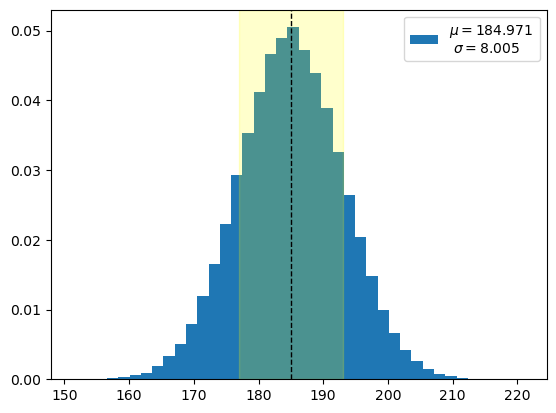

The probability that someone is 185 cm tall or less is 49.86 %
The probability that someone is within 8.01 of 185 cm is 68.27 %


In [3]:
# Q 4.4
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

h = np.random.normal(loc=185,scale=8,size=100000)

avg = np.mean(h)
std = np.std(h)

plt.hist(h, bins=40, label=f'$\mu=${avg:.3f} \n $\sigma=${std:.3f}', density=True)
plt.axvline(avg, color='k', linestyle='dashed', linewidth=1)
plt.axvspan(avg-std, avg+std, alpha=.2, color='yellow')
plt.legend()
plt.show()

cdf = norm.cdf(185, scale=std, loc=avg)
P = ( 1 - cdf ) * 100
print(f"The probability that someone is 185 cm tall or less is {P:.2f} %")

Plow = norm.cdf(avg-std, scale=std, loc=avg)
Phigh = norm.cdf(avg+std, scale=std, loc=avg)
Ptot = ( Phigh - Plow) * 100
print(f"The probability that someone is within {std:.2f} of 185 cm is {Ptot:.2f} %")

In [18]:
# Q 4.6
import numpy as np

def integrate(f,a,b):
    n = 10000000
    x = np.random.uniform(a,b,n)
    y = eval(f)
    integral = ( ( b - a ) / n ) * sum (y)
    return integral

f = input('f(x) =')
a = float(input('Lower boundary, a ='))
b = float(input('Upper boundary, b ='))

print(integrate(f,a,b))

f(x) = x
Lower boundary, a = 0
Upper boundary, b = 1


0.49996693548352467


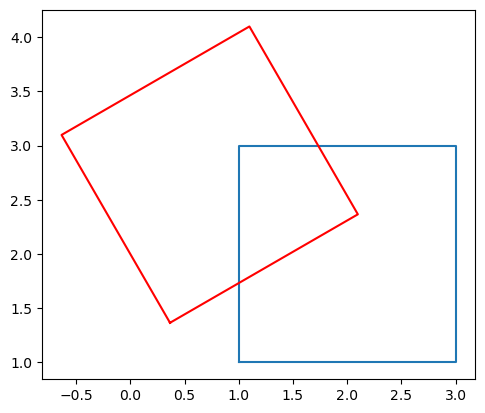

In [19]:
# Q 4.12
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1,3,3,1,1])
y = np.array([1,1,3,3,1])

angle = 30
theta = np.radians(angle)
rotor = np.cos(theta) + 1j * np.sin(theta)
xy = rotor * (x+y*1j)

plt.plot(x,y)
plt.plot(xy.real,xy.imag, color='red')
plt.gca().set_aspect(1)
plt.show()

In [139]:
# Q 4.14 
import numpy as np

def funcfilter(func, seq):
    seq = np.asarray([seq])
    print(seq)
    s = seq > 0
    n = seq[s]
    filt = func(n)
    return filt

sq = np.array([-100, -10, 0, 10, 100])
result = funcfilter(np.log10, sq)
print("Result log10:", result)

sq = 100
result = funcfilter(np.log10, sq)
print("Result log10:", result)

[[-100  -10    0   10  100]]
Result log10: [1. 2.]
[100]
Result log10: [2.]


In [152]:
# Q 4.16 
from astropy.cosmology import Planck18
from scipy import integrate
from math import sqrt

H0 = Planck18.H0.value
Om0 = Planck18.Om0
Ode0 = Planck18.Ode0

def t(z):
    y = 1 / ( ( 1 + z ) * ( H0 * sqrt( Om0 * ( 1 + z )**3 + Ode0 ) ) )     # units of s.Mpc/km
    return y

t2 = integrate.quad(t, 0, 2)
# convert to sec by multiplying by 5,3855e17 (km in a Mpc) and to years by dividing by 3600*24*365
t = t2[0] * 3.0856e19 / (3600*24*365) * 1e-9
print(f'{t:f} ± {(t2[1]*1e-9):.0e} Gyr')

10.533148 ± 2e-24 Gyr


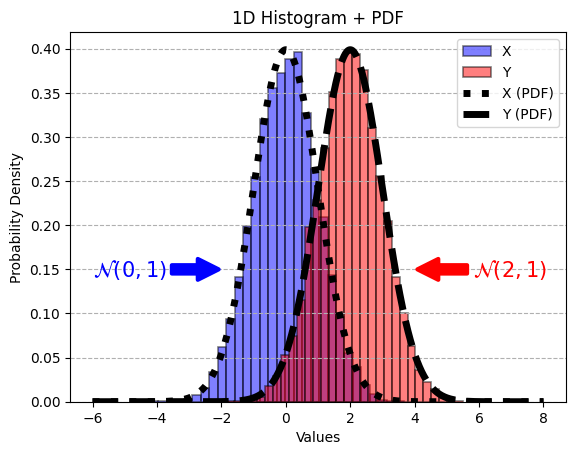

TypeError: Input z must be 2D, not 1D

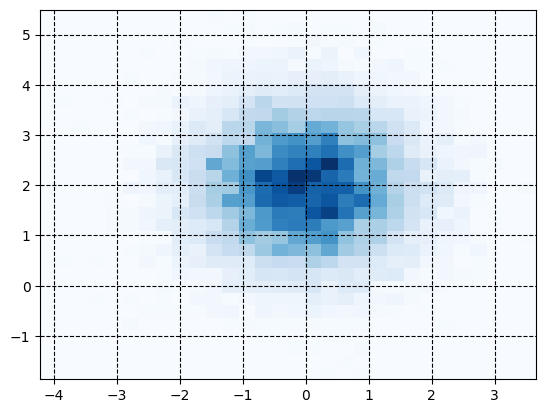

In [2]:
# Q 4.21 (pending)
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from scipy.stats import multivariate_normal

X = np.random.normal(0,1,10000)
Y = np.random.normal(2,1,10000)

x = np.linspace(-6,8,1000)


plt.hist(X,
         bins=30,
         density=True,
         color='blue',
         alpha=0.5,
         edgecolor='black',
         linewidth=1.2,
         label='X')
plt.hist(Y,
         bins=30,
         density=True,
         color='red',
         alpha=0.5,
         edgecolor='black',
         linewidth=1.2,
         label='Y')

plt.plot(x, norm.pdf(x,0,1),
         label='X (PDF)',
         color='black',
         linewidth=5,
         linestyle='dotted',)
plt.plot(x, norm.pdf(x,2,1),
         label='Y (PDF)',
         color='black',
         linewidth=5,
         linestyle='--',)

y_arrow = 0.15
plt.annotate(r'$\mathcal{N}(0,1)$',
            xy=(-2, y_arrow),
            xytext=(-6, y_arrow),
            fontsize=15,
            color='blue',
            va='center',
            arrowprops=dict(
                arrowstyle='simple',
                lw=3,
                color='blue',
                mutation_scale=30))
plt.annotate(r'$\mathcal{N}(2,1)$',
            xy=(4, y_arrow),
            xytext=(5.8, y_arrow),
            fontsize=15,
            color='red',
            va='center',
            arrowprops=dict(
                arrowstyle='simple',
                lw=3,
                color='red',
                mutation_scale=30))

plt.title('1D Histogram + PDF')
plt.xlabel('Values')
plt.ylabel('Probability Density')

plt.grid(axis='y',
         linestyle='--')
plt.legend()
plt.show()


plt.hist2d(X, Y,
           bins=30,
           cmap='Blues')

plt.grid(linestyle='--',
         color='black')

Xg, Yg = np.meshgrid(X, Y)
Z = np.linspace(0,0,1000)

plt.contour(Xg, Yg, Z,
            levels=(1*np.std(X),2*np.std(X),3*np.std(X)), vmin=0, vmax=1)

plt.title('2D Histogram + Contour')
plt.xlabel('X')
plt.ylabel('Y')

plt.colorbar()
plt.show()

/var/folders/n8/bghhq66s6v7g9hfd3_t25l7w0000gn/T/ipykernel_32299/392217888.py:25: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  zc = CS.collections[6]


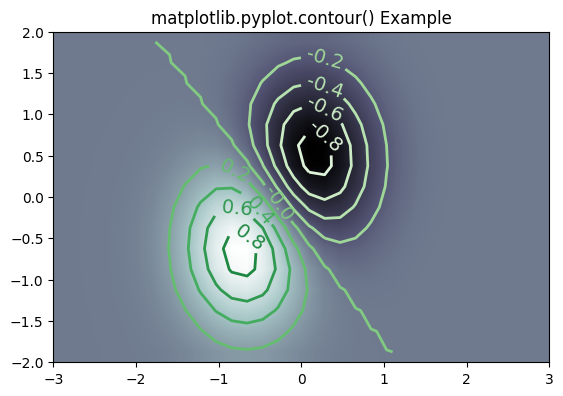

In [1]:
import matplotlib
import numpy as np
import matplotlib.cm as cm
import matplotlib.pyplot as plt

delta = 0.25
x = np.arange(-3.0, 5.0, delta)
y = np.arange(-1.3, 2.5, delta)
X, Y = np.meshgrid(x, y)
Z = (np.exp(-X**2 - Y**2) - np.exp(-(X - 1)**2 - (Y - 1)**2))

fig, ax = plt.subplots()
im = ax.imshow(Z, interpolation ='bilinear',
               origin ='lower',
               cmap ="bone",
               extent =(-3, 3, -2, 2))

levels = np.arange(-1.2, 1.6, 0.2)
CS = ax.contour(Z, levels,
                origin ='lower',
                cmap ='Greens',
                linewidths = 2,
                extent =(-3, 3, -2, 2))

zc = CS.collections[6]
plt.setp(zc, linewidth = 2)

ax.clabel(CS, levels,
          inline = 1,
          fmt ='% 1.1f',
          fontsize = 14)

plt.title('matplotlib.pyplot.contour() Example')
plt.show()